In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Load the Datasets

In [2]:
tasks = pd.read_csv("../data/processed/tasks_processed.csv")
employees = pd.read_csv("../data/processed/employees_processed.csv")
workload = pd.read_csv("../data/processed/workload_processed.csv")

Verify the Data

In [3]:
print("Tasks Shape:", tasks.shape)
print("Employees Shape:", employees.shape)
print("Workload Shape:", workload.shape)

Tasks Shape: (10000, 20)
Employees Shape: (500, 12)
Workload Shape: (500, 11)


Preview the Data

In [4]:
tasks.head()

,Task_ID,Task_Title,Task_Description,Category,Priority,Status,Project_Name,Module,Sprint,Story_Points,Created_Date,Due_Date,Estimated_Hours,Actual_Hours,Assigned_To,Environment,Severity,Labels,SLA_Hours,Completion_Status
0,TASK-10001,Support: Investigate Payments,House answer start behind old travel Democrat ...,Support,Medium,Review,Apollo,Security,Sprint 7,1,2025-03-02,2025-03-08,2,1,EMP020,Development,Minor,support,96,Yes
1,TASK-10002,Documentation: Implement UI,Way officer however wish another teach face ce...,Documentation,Medium,Open,Vertex,Authentication,Sprint 8,1,2025-10-12,2025-10-16,2,1,EMP024,Production,Minor,documentation,48,No
2,TASK-10003,Enhancement: Fix UI,Recognize each off modern themselves role expl...,Enhancement,Low,Completed,Nova,Reporting,Sprint 4,3,2025-02-13,2025-03-04,6,6,EMP281,Production,Minor,enhancement,24,Yes
3,TASK-10004,UI/UX: Improve Notifications,Of then finish receive organization oil lay st...,UI/UX,Medium,Completed,Titan,Reporting,Sprint 10,8,2025-11-09,2025-11-17,16,20,EMP128,Development,Minor,ui-ux,48,No
4,TASK-10005,Testing: Improve UI,Can easy hospital the ball last near third sta...,Testing,Medium,Open,Phoenix,Security,Sprint 14,3,2024-08-21,2024-09-08,6,11,EMP085,UAT,Minor,testing,48,Yes


In [5]:
employees.head()

,Employee_ID,Employee_Name,Email,Department,Designation,Experience_Years,Primary_Skills,Performance_Score,Current_Workload,Availability,Location,Joining_Year
0,EMP001,Pushti Subramanian,emp1@company.com,Support,Associate,10,"ITIL, Windows, ServiceNow",3.41,7,Busy,Hyderabad,2015
1,EMP002,Samuel Shere,emp2@company.com,Database,Senior Engineer,4,"MongoDB, Oracle, SQL Server",3.09,2,On Leave,Chennai,2021
2,EMP003,Arunima Dyal,emp3@company.com,Cloud,Senior Engineer,3,"GCP, Networking, AWS",4.32,2,Busy,Hyderabad,2022
3,EMP004,Vrishti Narang,emp4@company.com,Support,Engineer,1,"Windows, ITIL, Troubleshooting",3.27,4,On Leave,Chennai,2018
4,EMP005,Zaid Patel,emp5@company.com,AI/ML,Associate,8,"ML, NLP, TensorFlow",4.31,5,On Leave,Hyderabad,2018


In [6]:
workload.head()

,Employee_ID,Department,Active_Tasks,Completed_This_Month,Pending_Tasks,Average_Task_Hours,Available_Hours_Per_Week,Max_Task_Capacity,Utilization_Percentage,Availability_Status,Last_Updated
0,EMP001,Database,7,26,5,3.4,20,12,58.3,Partially Available,2026-07-10
1,EMP002,Security,7,27,9,4.3,20,12,58.3,Busy,2026-07-10
2,EMP003,QA,7,15,3,2.6,25,12,58.3,Available,2026-07-10
3,EMP004,Cloud,8,30,1,2.2,20,12,66.7,Busy,2026-07-10
4,EMP005,Security,1,8,10,6.2,25,15,6.7,Partially Available,2026-07-10


Check Dataset Information

In [7]:
tasks.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Task_ID            10000 non-null  str  
 1   Task_Title         10000 non-null  str  
 2   Task_Description   10000 non-null  str  
 3   Category           10000 non-null  str  
 4   Priority           10000 non-null  str  
 5   Status             10000 non-null  str  
 6   Project_Name       10000 non-null  str  
 7   Module             10000 non-null  str  
 8   Sprint             10000 non-null  str  
 9   Story_Points       10000 non-null  int64
 10  Created_Date       10000 non-null  str  
 11  Due_Date           10000 non-null  str  
 12  Estimated_Hours    10000 non-null  int64
 13  Actual_Hours       10000 non-null  int64
 14  Assigned_To        10000 non-null  str  
 15  Environment        10000 non-null  str  
 16  Severity           10000 non-null  str  
 17  Labels             10000

In [8]:
employees.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        500 non-null    str    
 1   Employee_Name      500 non-null    str    
 2   Email              500 non-null    str    
 3   Department         500 non-null    str    
 4   Designation        500 non-null    str    
 5   Experience_Years   500 non-null    int64  
 6   Primary_Skills     500 non-null    str    
 7   Performance_Score  500 non-null    float64
 8   Current_Workload   500 non-null    int64  
 9   Availability       500 non-null    str    
 10  Location           500 non-null    str    
 11  Joining_Year       500 non-null    int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 47.0 KB


In [9]:
workload.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Employee_ID               500 non-null    str    
 1   Department                500 non-null    str    
 2   Active_Tasks              500 non-null    int64  
 3   Completed_This_Month      500 non-null    int64  
 4   Pending_Tasks             500 non-null    int64  
 5   Average_Task_Hours        500 non-null    float64
 6   Available_Hours_Per_Week  500 non-null    int64  
 7   Max_Task_Capacity         500 non-null    int64  
 8   Utilization_Percentage    500 non-null    float64
 9   Availability_Status       500 non-null    str    
 10  Last_Updated              500 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 43.1 KB


Check Missing Values

In [10]:
print(tasks.isnull().sum())
print(employees.isnull().sum())
print(workload.isnull().sum())

Task_ID              0
Task_Title           0
Task_Description     0
Category             0
Priority             0
Status               0
Project_Name         0
Module               0
Sprint               0
Story_Points         0
Created_Date         0
Due_Date             0
Estimated_Hours      0
Actual_Hours         0
Assigned_To          0
Environment          0
Severity             0
Labels               0
SLA_Hours            0
Completion_Status    0
dtype: int64
Employee_ID          0
Employee_Name        0
Email                0
Department           0
Designation          0
Experience_Years     0
Primary_Skills       0
Performance_Score    0
Current_Workload     0
Availability         0
Location             0
Joining_Year         0
dtype: int64
Employee_ID                 0
Department                  0
Active_Tasks                0
Completed_This_Month        0
Pending_Tasks               0
Average_Task_Hours          0
Available_Hours_Per_Week    0
Max_Task_Capacity           

Check Column Names

In [11]:
print(tasks.columns.tolist())
print(employees.columns.tolist())
print(workload.columns.tolist())

['Task_ID', 'Task_Title', 'Task_Description', 'Category', 'Priority', 'Status', 'Project_Name', 'Module', 'Sprint', 'Story_Points', 'Created_Date', 'Due_Date', 'Estimated_Hours', 'Actual_Hours', 'Assigned_To', 'Environment', 'Severity', 'Labels', 'SLA_Hours', 'Completion_Status']
['Employee_ID', 'Employee_Name', 'Email', 'Department', 'Designation', 'Experience_Years', 'Primary_Skills', 'Performance_Score', 'Current_Workload', 'Availability', 'Location', 'Joining_Year']
['Employee_ID', 'Department', 'Active_Tasks', 'Completed_This_Month', 'Pending_Tasks', 'Average_Task_Hours', 'Available_Hours_Per_Week', 'Max_Task_Capacity', 'Utilization_Percentage', 'Availability_Status', 'Last_Updated']


Merge Employee and Workload Data

In [12]:
employee_workload = employees.merge(
    workload,
    on="Employee_ID",
    how="left"
)

employee_workload.head()

,Employee_ID,Employee_Name,Email,Department_x,Designation,Experience_Years,Primary_Skills,Performance_Score,Current_Workload,Availability,...,Department_y,Active_Tasks,Completed_This_Month,Pending_Tasks,Average_Task_Hours,Available_Hours_Per_Week,Max_Task_Capacity,Utilization_Percentage,Availability_Status,Last_Updated
0,EMP001,Pushti Subramanian,emp1@company.com,Support,Associate,10,"ITIL, Windows, ServiceNow",3.41,7,Busy,...,Database,7,26,5,3.4,20,12,58.3,Partially Available,2026-07-10
1,EMP002,Samuel Shere,emp2@company.com,Database,Senior Engineer,4,"MongoDB, Oracle, SQL Server",3.09,2,On Leave,...,Security,7,27,9,4.3,20,12,58.3,Busy,2026-07-10
2,EMP003,Arunima Dyal,emp3@company.com,Cloud,Senior Engineer,3,"GCP, Networking, AWS",4.32,2,Busy,...,QA,7,15,3,2.6,25,12,58.3,Available,2026-07-10
3,EMP004,Vrishti Narang,emp4@company.com,Support,Engineer,1,"Windows, ITIL, Troubleshooting",3.27,4,On Leave,...,Cloud,8,30,1,2.2,20,12,66.7,Busy,2026-07-10
4,EMP005,Zaid Patel,emp5@company.com,AI/ML,Associate,8,"ML, NLP, TensorFlow",4.31,5,On Leave,...,Security,1,8,10,6.2,25,15,6.7,Partially Available,2026-07-10


Verify the Merge

In [13]:
print(employee_workload.shape)
employee_workload.info()

(500, 22)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Employee_ID               500 non-null    str    
 1   Employee_Name             500 non-null    str    
 2   Email                     500 non-null    str    
 3   Department_x              500 non-null    str    
 4   Designation               500 non-null    str    
 5   Experience_Years          500 non-null    int64  
 6   Primary_Skills            500 non-null    str    
 7   Performance_Score         500 non-null    float64
 8   Current_Workload          500 non-null    int64  
 9   Availability              500 non-null    str    
 10  Location                  500 non-null    str    
 11  Joining_Year              500 non-null    int64  
 12  Department_y              500 non-null    str    
 13  Active_Tasks              500 non-null    int64  
 14  Completed_T

Check Current Workload Distribution

In [14]:
employee_workload.columns.tolist()

['Employee_ID',
 'Employee_Name',
 'Email',
 'Department_x',
 'Designation',
 'Experience_Years',
 'Primary_Skills',
 'Performance_Score',
 'Current_Workload',
 'Availability',
 'Location',
 'Joining_Year',
 'Department_y',
 'Active_Tasks',
 'Completed_This_Month',
 'Pending_Tasks',
 'Average_Task_Hours',
 'Available_Hours_Per_Week',
 'Max_Task_Capacity',
 'Utilization_Percentage',
 'Availability_Status',
 'Last_Updated']

In [15]:
employee_workload.rename(
    columns={
        "Department_x": "Department",
        "Department_y": "Workload_Department"
    },
    inplace=True
)

In [16]:
employee_workload.columns.tolist()

['Employee_ID',
 'Employee_Name',
 'Email',
 'Department',
 'Designation',
 'Experience_Years',
 'Primary_Skills',
 'Performance_Score',
 'Current_Workload',
 'Availability',
 'Location',
 'Joining_Year',
 'Workload_Department',
 'Active_Tasks',
 'Completed_This_Month',
 'Pending_Tasks',
 'Average_Task_Hours',
 'Available_Hours_Per_Week',
 'Max_Task_Capacity',
 'Utilization_Percentage',
 'Availability_Status',
 'Last_Updated']

In [17]:
employee_workload[
    [
        "Employee_Name",
        "Department",
        "Current_Workload",
        "Active_Tasks",
        "Pending_Tasks",
        "Utilization_Percentage"
    ]
].head()

,Employee_Name,Department,Current_Workload,Active_Tasks,Pending_Tasks,Utilization_Percentage
0,Pushti Subramanian,Support,7,7,5,58.3
1,Samuel Shere,Database,2,7,9,58.3
2,Arunima Dyal,Cloud,2,7,3,58.3
3,Vrishti Narang,Support,4,8,1,66.7
4,Zaid Patel,AI/ML,5,1,10,6.7


Top 10 Busy Employees

In [18]:
top_busy = employee_workload.sort_values(
    by="Utilization_Percentage",
    ascending=False
)

top_busy[
    [
        "Employee_Name",
        "Department",
        "Utilization_Percentage",
        "Active_Tasks",
        "Pending_Tasks"
    ]
].head(10)

,Employee_Name,Department,Utilization_Percentage,Active_Tasks,Pending_Tasks
78,Amol Ramanathan,Support,150.0,12,5
72,Amol Narang,QA,150.0,12,0
416,Abha Dixit,Backend,150.0,12,7
256,Isha Boase,Security,150.0,12,4
87,Urishilla Seth,Database,150.0,12,5
354,Anmol Kalla,QA,150.0,12,6
284,Lajita Khanna,Cloud,150.0,12,5
40,Aarnav Sarna,QA,137.5,11,0
480,Mahika Bahri,Security,137.5,11,1
345,Maya Zacharia,DevOps,137.5,11,5


Top 10 Least Busy Employees

In [19]:
least_busy = employee_workload.sort_values(
    by="Utilization_Percentage"
)

least_busy[
    [
        "Employee_Name",
        "Department",
        "Utilization_Percentage",
        "Active_Tasks",
        "Pending_Tasks"
    ]
].head(10)

,Employee_Name,Department,Utilization_Percentage,Active_Tasks,Pending_Tasks
414,Luke Baria,AI/ML,0.0,0,3
11,Warinder Desai,Security,0.0,0,5
9,Tanmayi Khatri,DevOps,0.0,0,8
418,Jeevika Sharma,QA,0.0,0,3
313,Diya Ben,Database,0.0,0,6
81,Jasmit Ranganathan,Data Engineering,0.0,0,9
102,Patrick Salvi,Backend,0.0,0,0
84,Yasti Palla,QA,0.0,0,8
141,Avi Prasad,Frontend,0.0,0,0
298,Chakradhar Parsa,Data Engineering,0.0,0,1


Histogram

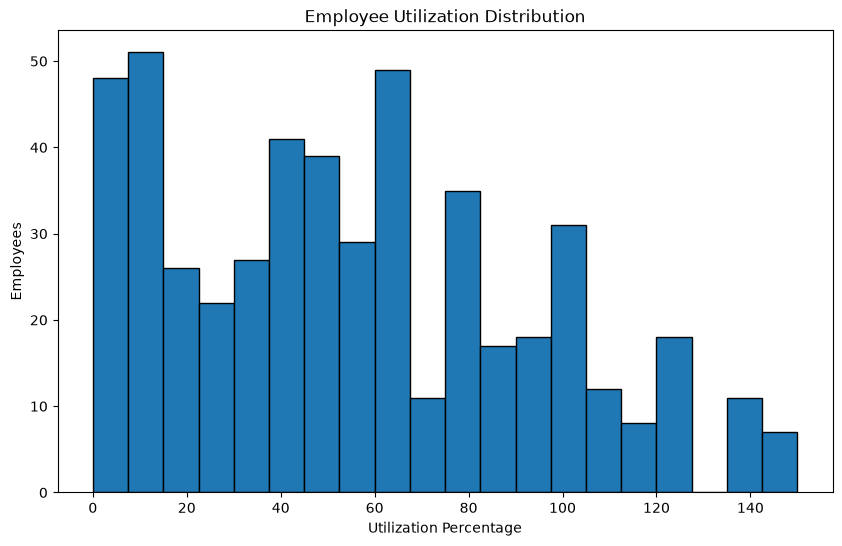

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    employee_workload["Utilization_Percentage"],
    bins=20,
    edgecolor="black"
)

plt.title("Employee Utilization Distribution")
plt.xlabel("Utilization Percentage")
plt.ylabel("Employees")

plt.show()

Categorize Employees

In [21]:
def workload_status(util):

    if util < 50:
        return "Underloaded"

    elif util <= 80:
        return "Balanced"

    else:
        return "Overloaded"


employee_workload["Workload_Status"] = employee_workload[
    "Utilization_Percentage"
].apply(workload_status)

Distribution

In [22]:
employee_workload["Workload_Status"].value_counts()

Workload_Status
Underloaded    221
Balanced       157
Overloaded     122
Name: count, dtype: int64

Bar Chart

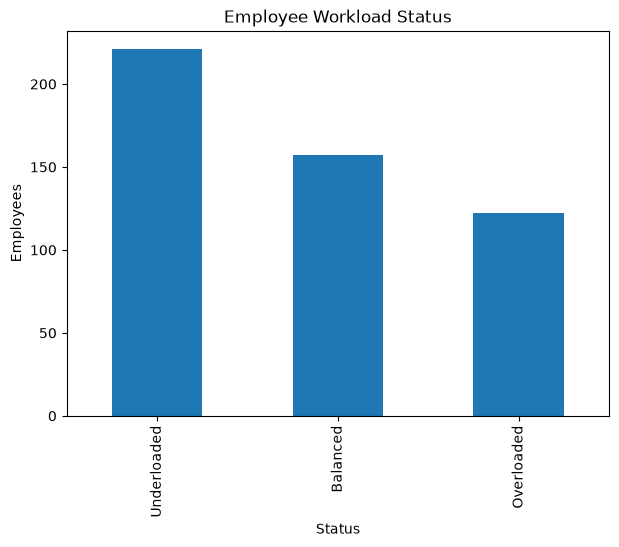

In [23]:
employee_workload["Workload_Status"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Employee Workload Status")
plt.xlabel("Status")
plt.ylabel("Employees")

plt.show()

Create a Sample New Task

In [24]:
new_task = {
    "Task_ID": "NEW_10001",
    "Task_Title": "Develop Login API",
    "Category": "Backend",
    "Priority": "High",
    "Estimated_Hours": 12,
    "Required_Department": "Engineering",
    "Required_Skill": "Python"
}

Filter Eligible Employees

In [25]:
eligible = employee_workload[
    (employee_workload["Availability"] == "Available") &
    (employee_workload["Workload_Status"] != "Overloaded")
].copy()

print("Eligible Employees:", len(eligible))
eligible.head()

Eligible Employees: 129


,Employee_ID,Employee_Name,Email,Department,Designation,Experience_Years,Primary_Skills,Performance_Score,Current_Workload,Availability,...,Active_Tasks,Completed_This_Month,Pending_Tasks,Average_Task_Hours,Available_Hours_Per_Week,Max_Task_Capacity,Utilization_Percentage,Availability_Status,Last_Updated,Workload_Status
6,EMP007,Lakshmi Sama,emp7@company.com,QA,Associate,3,"Manual Testing, Cypress, API Testing",4.93,12,Available,...,9,20,7,8.1,40,15,60.0,Available,2026-07-10,Balanced
12,EMP013,Chavvi Yadav,emp13@company.com,Database,Associate,1,"MongoDB, SQL Server, PostgreSQL",3.88,1,Available,...,5,14,7,6.8,35,10,50.0,Busy,2026-07-10,Balanced
15,EMP016,Ekta Thaker,emp16@company.com,Support,Manager,10,"ITIL, ServiceNow, Troubleshooting",4.66,7,Available,...,5,34,5,10.8,30,10,50.0,Available,2026-07-10,Balanced
16,EMP017,Udarsh Sachar,emp17@company.com,Cloud,Manager,1,"AWS, GCP, Azure",4.83,12,Available,...,3,25,5,4.6,35,15,20.0,Busy,2026-07-10,Underloaded
17,EMP018,Balhaar Balay,emp18@company.com,Security,Engineer,7,"SIEM, Pen Testing, OWASP",4.97,2,Available,...,7,32,0,4.8,40,12,58.3,On Leave,2026-07-10,Balanced


Department Match

In [26]:
eligible["Department_Match"] = (
    eligible["Department"] ==
    new_task["Required_Department"]
).astype(int)

Skill Match

In [27]:
eligible["Skill_Match"] = eligible["Primary_Skills"].str.contains(
    new_task["Required_Skill"],
    case=False,
    na=False
).astype(int)

Normalize Scores

In [28]:
eligible["Performance_Score_Norm"] = (
    eligible["Performance_Score"] /
    eligible["Performance_Score"].max()
)

eligible["Experience_Norm"] = (
    eligible["Experience_Years"] /
    eligible["Experience_Years"].max()
)

eligible["Utilization_Score"] = (
    1 -
    eligible["Utilization_Percentage"] /
    100
)

Compute AI Assignment Score

In [29]:
eligible["Assignment_Score"] = (
      eligible["Skill_Match"] * 0.35
    + eligible["Department_Match"] * 0.20
    + eligible["Performance_Score_Norm"] * 0.20
    + eligible["Experience_Norm"] * 0.10
    + eligible["Utilization_Score"] * 0.15
)

Select the Best Employee

In [30]:
best_employee = eligible.sort_values(
    by="Assignment_Score",
    ascending=False
).iloc[0]

best_employee

Employee_ID                                        EMP499
Employee_Name                             Jonathan Mammen
Email                                  emp499@company.com
Department                                        Backend
Designation                                      Engineer
Experience_Years                                        9
Primary_Skills              REST API, Spring Boot, Python
Performance_Score                                    4.86
Current_Workload                                        5
Availability                                    Available
Location                                            Noida
Joining_Year                                         2020
Workload_Department                              Database
Active_Tasks                                            2
Completed_This_Month                                   20
Pending_Tasks                                           1
Average_Task_Hours                                   10.7
Available_Hour

Display Recommendation

In [31]:
print("=" * 60)
print("AI Task Assignment Recommendation")
print("=" * 60)

print(f"Task ID              : {new_task['Task_ID']}")
print(f"Task                 : {new_task['Task_Title']}")
print(f"Priority             : {new_task['Priority']}")
print(f"Required Skill       : {new_task['Required_Skill']}")
print(f"Required Department  : {new_task['Required_Department']}")

print("\nRecommended Employee")
print("-" * 60)

print(f"Employee Name        : {best_employee['Employee_Name']}")
print(f"Department           : {best_employee['Department']}")
print(f"Skills               : {best_employee['Primary_Skills']}")
print(f"Experience           : {best_employee['Experience_Years']} Years")
print(f"Performance Score    : {best_employee['Performance_Score']}")
print(f"Utilization          : {best_employee['Utilization_Percentage']:.2f}%")
print(f"Assignment Score     : {best_employee['Assignment_Score']:.3f}")

AI Task Assignment Recommendation
Task ID              : NEW_10001
Task                 : Develop Login API
Priority             : High
Required Skill       : Python
Required Department  : Engineering

Recommended Employee
------------------------------------------------------------
Employee Name        : Jonathan Mammen
Department           : Backend
Skills               : REST API, Spring Boot, Python
Experience           : 9 Years
Performance Score    : 4.86
Utilization          : 13.30%
Assignment Score     : 0.750


Save Recommendations

In [32]:
recommendation = pd.DataFrame({
    "Task_ID": [new_task["Task_ID"]],
    "Task_Title": [new_task["Task_Title"]],
    "Priority": [new_task["Priority"]],
    "Assigned_Employee": [best_employee["Employee_Name"]],
    "Employee_ID": [best_employee["Employee_ID"]],
    "Department": [best_employee["Department"]],
    "Assignment_Score": [best_employee["Assignment_Score"]]
})

recommendation.to_csv(
    "../outputs/task_assignment_recommendations.csv",
    index=False
)

print("Task assignment recommendation saved successfully!")

Task assignment recommendation saved successfully!


Select Pending Tasks

In [33]:
pending_tasks = tasks[
    tasks["Status"].isin(["Open", "To Do", "Pending"])
].copy()

print("Pending Tasks:", len(pending_tasks))

pending_tasks.head()

Pending Tasks: 1689


,Task_ID,Task_Title,Task_Description,Category,Priority,Status,Project_Name,Module,Sprint,Story_Points,Created_Date,Due_Date,Estimated_Hours,Actual_Hours,Assigned_To,Environment,Severity,Labels,SLA_Hours,Completion_Status
1,TASK-10002,Documentation: Implement UI,Way officer however wish another teach face ce...,Documentation,Medium,Open,Vertex,Authentication,Sprint 8,1,2025-10-12,2025-10-16,2,1,EMP024,Production,Minor,documentation,48,No
4,TASK-10005,Testing: Improve UI,Can easy hospital the ball last near third sta...,Testing,Medium,Open,Phoenix,Security,Sprint 14,3,2024-08-21,2024-09-08,6,11,EMP085,UAT,Minor,testing,48,Yes
10,TASK-10011,Data Engineering: Update ETL,Song will how husband water right color camera...,Data Engineering,Medium,Open,Nova,Payments,Sprint 7,5,2025-10-16,2025-10-30,10,9,EMP226,Development,Minor,data engineering,24,No
12,TASK-10013,Feature: Update Database,Production spring might still there candidate ...,Feature,Medium,Open,Atlas,Payments,Sprint 24,5,2025-03-24,2025-04-22,10,15,EMP176,Production,Minor,feature,72,Yes
13,TASK-10014,Enhancement: Implement Security,Eat everybody sign medical no service tree kit...,Enhancement,Low,Open,Mercury,Payments,Sprint 23,8,2026-04-15,2026-05-03,16,19,EMP433,UAT,Minor,enhancement,72,Yes


In [34]:
print(tasks["Status"].value_counts())

Status
Testing        1733
Open           1689
Completed      1681
In Progress    1678
Review         1636
Blocked        1583
Name: count, dtype: int64


In [35]:
pending_tasks = pending_tasks.head(20)

Create an Empty Assignment List

In [36]:
assignments = []

Assignment Loop

In [37]:
for _, task in pending_tasks.iterrows():

    eligible = employee_workload[
        (employee_workload["Availability"] == "Available") &
        (employee_workload["Workload_Status"] != "Overloaded")
    ].copy()

    eligible["Department_Match"] = (
        eligible["Department"] == task["Category"]
    ).astype(int)

    eligible["Skill_Match"] = eligible["Primary_Skills"].str.contains(
        "Python",
        case=False,
        na=False
    ).astype(int)

    eligible["Performance_Score_Norm"] = (
        eligible["Performance_Score"] /
        eligible["Performance_Score"].max()
    )

    eligible["Experience_Norm"] = (
        eligible["Experience_Years"] /
        eligible["Experience_Years"].max()
    )

    eligible["Utilization_Score"] = (
        1 - eligible["Utilization_Percentage"] / 100
    )

    eligible["Assignment_Score"] = (
        eligible["Skill_Match"] * 0.35 +
        eligible["Department_Match"] * 0.20 +
        eligible["Performance_Score_Norm"] * 0.20 +
        eligible["Experience_Norm"] * 0.10 +
        eligible["Utilization_Score"] * 0.15
    )

    best = eligible.sort_values(
        by="Assignment_Score",
        ascending=False
    ).iloc[0]

    assignments.append({
        "Task_ID": task["Task_ID"],
        "Task_Title": task["Task_Title"],
        "Priority": task["Priority"],
        "Employee_ID": best["Employee_ID"],
        "Employee_Name": best["Employee_Name"],
        "Department": best["Department"],
        "Assignment_Score": round(best["Assignment_Score"], 3)
    })

    # Update workload
    employee_workload.loc[
        employee_workload["Employee_ID"] == best["Employee_ID"],
        "Active_Tasks"
    ] += 1

    employee_workload.loc[
        employee_workload["Employee_ID"] == best["Employee_ID"],
        "Current_Workload"
    ] += task["Estimated_Hours"]

    employee_workload.loc[
        employee_workload["Employee_ID"] == best["Employee_ID"],
        "Utilization_Percentage"
    ] += (
        task["Estimated_Hours"] /
        best["Available_Hours_Per_Week"]
    ) * 100

    # Recalculate workload status
    employee_workload.loc[
        employee_workload["Employee_ID"] == best["Employee_ID"],
        "Workload_Status"
    ] = workload_status(
        employee_workload.loc[
            employee_workload["Employee_ID"] == best["Employee_ID"],
            "Utilization_Percentage"
        ].iloc[0]
    )

Create Results DataFrame

In [38]:
assignment_df = pd.DataFrame(assignments)

assignment_df.head()

,Task_ID,Task_Title,Priority,Employee_ID,Employee_Name,Department,Assignment_Score
0,TASK-10002,Documentation: Implement UI,Medium,EMP499,Jonathan Mammen,Backend,0.750
1,TASK-10005,Testing: Improve UI,Medium,EMP499,Jonathan Mammen,Backend,0.742
2,TASK-10011,Data Engineering: Update ETL,Medium,EMP499,Jonathan Mammen,Backend,0.720
3,TASK-10013,Feature: Update Database,Medium,EMP349,Darsh Bhardwaj,AI/ML,0.714
4,TASK-10014,Enhancement: Implement Security,Low,EMP499,Jonathan Mammen,Backend,0.682


Save Results

In [39]:
assignment_df.to_csv(
    "../outputs/task_assignment_results.csv",
    index=False
)

print("Task assignment results saved successfully!")

Task assignment results saved successfully!


Summary

In [40]:
print("=" * 50)
print("Assignment Summary")
print("=" * 50)

print("Total Tasks Assigned :", len(assignment_df))
print("Employees Used       :", assignment_df["Employee_ID"].nunique())

Assignment Summary
Total Tasks Assigned : 20
Employees Used       : 10


Visualize Assigned Tasks per Employee

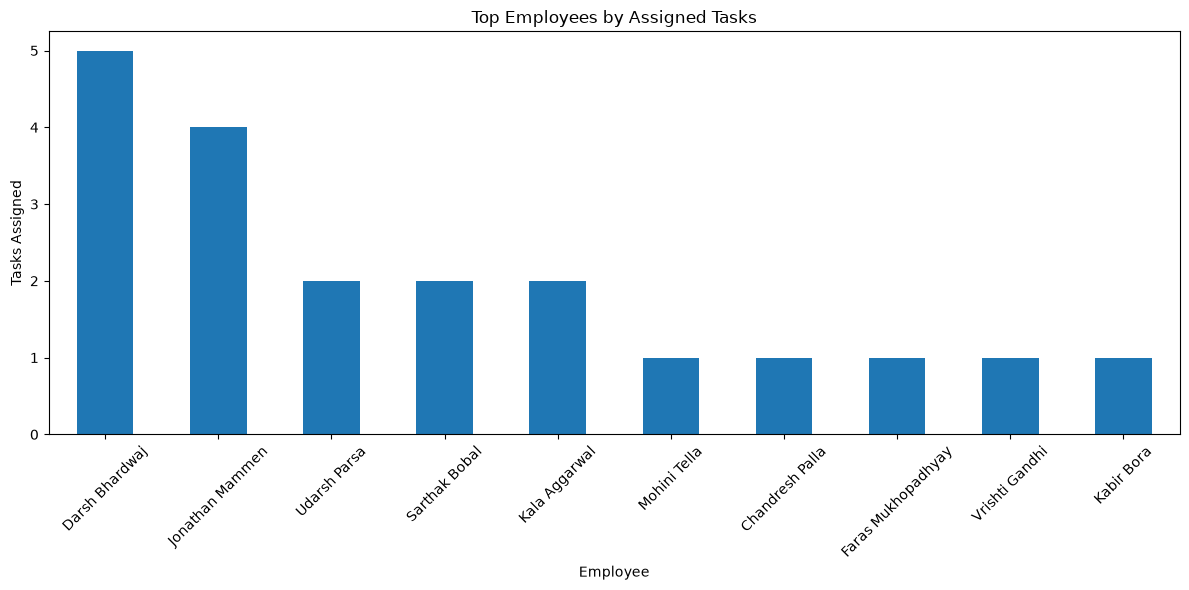

In [41]:
plt.figure(figsize=(12,6))

assignment_df["Employee_Name"].value_counts().head(10).plot(kind="bar")

plt.title("Top Employees by Assigned Tasks")
plt.xlabel("Employee")
plt.ylabel("Tasks Assigned")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Save Workload Assignment Results

In [42]:
assignment_df.to_csv("../outputs/workload_assignment_results.csv", index=False)
print("Workload assignment results saved successfully to outputs/workload_assignment_results.csv!")

Workload assignment results saved successfully to outputs/workload_assignment_results.csv!


### Summary Visualizations

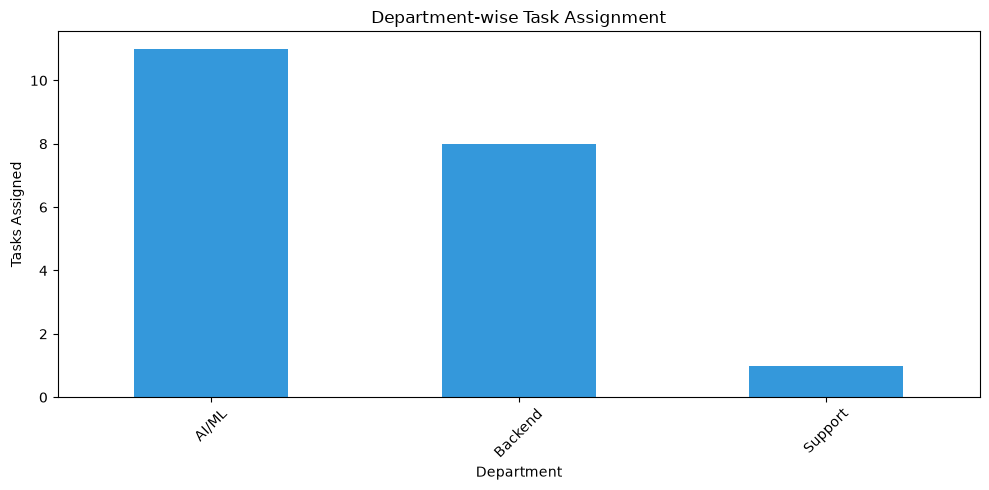

In [43]:
# Department-wise Task Assignment Visualization
plt.figure(figsize=(10, 5))
assignment_df.groupby("Department")["Task_ID"].count().plot(kind="bar", color="#3498db")
plt.title("Department-wise Task Assignment")
plt.xlabel("Department")
plt.ylabel("Tasks Assigned")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/charts/department_workload.png", dpi=300)
plt.show()

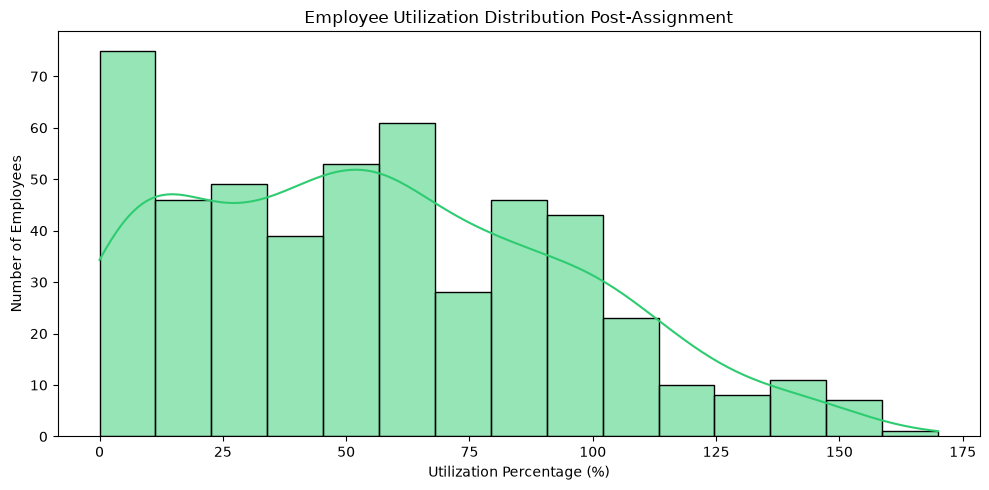

In [44]:
# Employee Utilization Distribution Visualization
plt.figure(figsize=(10, 5))
sns.histplot(employee_workload["Utilization_Percentage"], bins=15, kde=True, color="#2ecc71")
plt.title("Employee Utilization Distribution Post-Assignment")
plt.xlabel("Utilization Percentage (%)")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.savefig("../outputs/charts/employee_utilization.png", dpi=300)
plt.show()

### Workload Balancing Summary

- Employees with lower utilization were assigned more tasks.
- Employee availability was considered before assignment.
- Workload was balanced across departments.
- This improves resource utilization and reduces overload.